In [23]:
!pip install -q pykrige libpysal esda open_clip_torch zarr

In [24]:
import os, json, hashlib, math, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pykrige.ok3d import OrdinaryKriging3D
from pykrige.ok import OrdinaryKriging
from libpysal.weights import DistanceBand
from esda.moran import Moran, Moran_Local
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [25]:
# Paths Kaggle (defensivo) — DAGMA y MODIS en datasets separados
INPUT = Path('/kaggle/input')
WORKING = Path('/kaggle/working/sit3_endtoend')
WORKING.mkdir(parents=True, exist_ok=True)

def find_kaggle_path(*candidatos):
    for c in candidatos:
        p = INPUT / c
        if p.exists():
            return p
    raise FileNotFoundError(f'Ninguno encontrado: {candidatos}')

PANEL_PATH = find_kaggle_path('geovision-fuentes', 'datasets/juanjoseorozcolopez/geovision-fuentes')
DAGMA_DIR = find_kaggle_path('dagma-cristian-2021-2025-combinado', 'datasets/edwardsx/dagma-cristian-2021-2025-combinado')
MODELO_PATH = find_kaggle_path('geovision-clip-sit2-model', 'datasets/edwardsx/geovision-clip-sit2-model')

# MODIS v2 panel (escala verdadera) — opcional, solo si está disponible
MODIS_PATH = None
for c in ['modis-v2-panel', 'datasets/edwardsx/modis-v2-panel']:
    p = INPUT / c
    if p.exists():
        MODIS_PATH = p
        break

# Embeddings precomputados como Kaggle Dataset (si ya se generaron y subieron)
EMB_DATASET_PATH = None
for c in ['geovision-sit3-embeddings', 'datasets/edwardsx/geovision-sit3-embeddings']:
    p = INPUT / c
    if p.exists():
        EMB_DATASET_PATH = p
        break

DAGMA_CANDIDATOS = [
    DAGMA_DIR / 'df_dagma_unificado_coordenadas_limpias.parquet',
    DAGMA_DIR / 'df_dagma_unificado_master.parquet',
]
DAGMA_PATH = next((p for p in DAGMA_CANDIDATOS if p.exists()), None)
if DAGMA_PATH is None:
    parquets = list(DAGMA_DIR.rglob('*.parquet'))
    if parquets:
        DAGMA_PATH = parquets[0]
        print(f'WARN: usando parquet detectado: {DAGMA_PATH.name}')
assert DAGMA_PATH is not None, f'DAGMA no encontrado en {DAGMA_DIR}'

print(f'PANEL_PATH:        {PANEL_PATH}')
print(f'MODELO_PATH:       {MODELO_PATH}')
print(f'DAGMA_PATH:        {DAGMA_PATH}')
print(f'MODIS_PATH:        {MODIS_PATH if MODIS_PATH else "(no disponible, usando MODIS unido en DAGMA)"}')
print(f'EMB_DATASET_PATH:  {EMB_DATASET_PATH if EMB_DATASET_PATH else "(no disponible, se generara)"}')
print(f'WORKING:           {WORKING}')

PANEL_PATH:        /kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes
MODELO_PATH:       /kaggle/input/datasets/edwardsx/geovision-clip-sit2-model
DAGMA_PATH:        /kaggle/input/datasets/edwardsx/dagma-cristian-2021-2025-combinado/df_dagma_unificado_coordenadas_limpias.parquet
MODIS_PATH:        /kaggle/input/datasets/edwardsx/modis-v2-panel
EMB_DATASET_PATH:  /kaggle/input/datasets/edwardsx/geovision-sit3-embeddings
WORKING:           /kaggle/working/sit3_endtoend


In [26]:
# Constantes proyecto
BBOX = (-76.65, 3.30, -76.30, 3.65)  # lon_min, lat_min, lon_max, lat_max
TILE_PX = 64
ESCALA_M = 10.0
TILE_DEG = (TILE_PX * ESCALA_M) / 111_000
POLLUTANTS = ['NO2', 'SO2', 'O3']
HORIZONS = [1, 3, 7]  # días
WINDOW = 8  # secuencias de 8 fechas
EMBED_DIM = 256  # SAE sparse del modelo Sit 2
GRID_RES = 0.005  # resolución de grilla predicción en grados (~555 m)

In [27]:
# Cargar DAGMA + agregación diaria por estación-gas
dagma = pd.read_parquet(DAGMA_PATH)
dagma['fecha'] = pd.to_datetime(dagma['fecha'])
dagma['dia'] = dagma['fecha'].dt.normalize()

# Normalizar nombre del gas a mayúsculas
dagma['gas'] = dagma['tipo_gas'].str.upper()

# Filtrar a contaminantes objetivo y rango temporal con overlap S2/S5P
dagma = dagma[dagma.gas.isin(POLLUTANTS)]
dagma = dagma[(dagma.fecha >= '2021-01-01') & (dagma.fecha <= '2024-12-31')]

# Agregación diaria: mediana de horas válidas (robusto a outliers)
dagma_diario = (
    dagma.groupby(['nombre_est', 'gas', 'dia', 'latitud', 'longitud'])
    .concentracion.median()
    .reset_index()
    .dropna(subset=['concentracion'])
)

print(f'DAGMA total filas: {len(dagma):,}')
print(f'DAGMA diario filas: {len(dagma_diario):,}')
print('\nCobertura por gas:')
print(dagma_diario.groupby('gas').agg(
    estaciones=('nombre_est', 'nunique'),
    fechas=('dia', 'nunique'),
    obs=('concentracion', 'size'),
    mean=('concentracion', 'mean'),
    std=('concentracion', 'std'),
).round(2))

DAGMA total filas: 299,824
DAGMA diario filas: 14,363

Cobertura por gas:
     estaciones  fechas   obs   mean   std
gas                                       
NO2           2    1092  1233   9.82  4.64
O3            7    1461  7958  12.00  7.06
SO2           5    1461  5172   3.34  3.12


In [28]:
# Cargar checkpoint Sit 2 → reconstruir modelo CLIP-SAE
import open_clip
from transformers import AutoTokenizer, AutoModel

CHECKPOINT = MODELO_PATH / 'best_geovision_clip_sit2.pt'
if not CHECKPOINT.exists():
    candidates = list(MODELO_PATH.rglob('*.pt'))
    if candidates:
        CHECKPOINT = candidates[0]
        print(f'Usando: {CHECKPOINT}')

ckpt = torch.load(CHECKPOINT, map_location=device)
config_mod = ckpt.get('config', {})
print(f'Checkpoint epoch: {ckpt.get("epoch")}')
print(f'Config keys: {list(config_mod.keys())}')

# Constantes del modelo (mismas que Sit 2)
CHANNELS_S2 = 13
CONTRASTIVE_DIM = config_mod.get('contrastive_dim', 256)
SAE_SPARSE_DIM = config_mod.get('sae_sparse_dim', 256)
SAE_HIDDEN_VISUAL = config_mod.get('sae_hidden_visual', 2048)

Usando: /kaggle/input/datasets/edwardsx/geovision-clip-sit2-model/geovision_clip_sit2_best.pt
Checkpoint epoch: 26
Config keys: ['classes', 'features', 'contrastive_dim', 'sae_sparse_dim', 'sae_hidden_visual', 'sae_hidden_text', 'temp_init', 'seed', 'learning_rate', 'weight_decay', 'aux_cls_weight', 'label_smoothing', 'sae_l1_reg', 'train_last_blocks', 'tabular_dropout', 'best_beta']


In [29]:
# Re-definir arquitectura (idéntica a Sit 2 Bloque 3)
class BandProjector(nn.Module):
    def __init__(self, in_channels=13, out_channels=3, image_size=224):
        super().__init__()
        self.image_size = image_size
        self.proj = nn.Sequential(nn.Conv2d(in_channels, 32, 1), nn.GELU(), nn.Conv2d(32, out_channels, 1))
        self.register_buffer('mean', torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1))
    def forward(self, x):
        x = x / 10000.0
        x = torch.clamp(x, 0.0, 1.5)
        x = self.proj(x)
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode='bilinear', align_corners=False)
        x = torch.sigmoid(x)
        return (x - self.mean) / self.std

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=2048, sparse_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, sparse_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(sparse_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

class GeoVisionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
        self.band_projector = BandProjector(CHANNELS_S2, 3, 224)
        self.visual_encoder = clip_model.visual
        self.sae_visual = SparseAutoencoder(512, SAE_HIDDEN_VISUAL, SAE_SPARSE_DIM)
    @torch.no_grad()
    def embed(self, imgs):
        x = self.band_projector(imgs)
        raw = self.visual_encoder(x).float()
        z, _ = self.sae_visual(raw)
        return z  # (B, SAE_SPARSE_DIM)

encoder = GeoVisionEncoder().to(device).eval()

# Cargar solo los pesos relevantes del checkpoint Sit 2
state = ckpt['model_state']
subset = {k.replace('band_projector.', 'band_projector.'): v for k, v in state.items() if k.startswith('band_projector.') or k.startswith('visual_encoder.') or k.startswith('sae_visual.')}
missing, unexpected = encoder.load_state_dict(subset, strict=False)
print(f'Carga checkpoint: missing={len(missing)}, unexpected={len(unexpected)}')
print(f'Parámetros encoder: {sum(p.numel() for p in encoder.parameters()):,}')

Carga checkpoint: missing=0, unexpected=0
Parámetros encoder: 91,008,547


In [30]:
# Abrir paneles Zarr + parsear fechas S2 (formato granule ID)
ds_s2 = xr.open_zarr(PANEL_PATH / 'copernicus_s2_sr_harmonized' / 'panel.zarr', consolidated=False)
ds_no2 = xr.open_zarr(PANEL_PATH / 'copernicus_s5p_offl_l3_no2' / 'panel.zarr', consolidated=False)
ds_so2 = xr.open_zarr(PANEL_PATH / 'copernicus_s5p_offl_l3_so2' / 'panel.zarr', consolidated=False)
ds_o3 = xr.open_zarr(PANEL_PATH / 'copernicus_s5p_offl_l3_o3' / 'panel.zarr', consolidated=False)

print(f'S2:  {dict(ds_s2.sizes)}')
print(f'NO2: {dict(ds_no2.sizes)}')
print(f'SO2: {dict(ds_so2.sizes)}')
print(f'O3:  {dict(ds_o3.sizes)}')

def parse_s2_time(time_values):
    """S2 time puede venir como granule ID '20210103T152641_20210103T153117_T18NUJ' o como datetime nativo."""
    arr = np.asarray(time_values)
    if arr.dtype.kind == 'M':
        return pd.DatetimeIndex(arr)
    fechas = []
    for v in arr:
        s = str(v)
        try:
            f = pd.Timestamp(f'{s[:4]}-{s[4:6]}-{s[6:8]}T{s[9:11]}:{s[11:13]}:{s[13:15]}')
        except Exception:
            try:
                f = pd.Timestamp(f'{s[:4]}-{s[4:6]}-{s[6:8]}')
            except Exception:
                f = pd.NaT
        fechas.append(f)
    return pd.DatetimeIndex(fechas)

def parse_s5p_time(time_values):
    """S5P time típicamente datetime64; defensivo."""
    arr = np.asarray(time_values)
    if arr.dtype.kind == 'M':
        return pd.DatetimeIndex(arr)
    return pd.to_datetime([str(v) for v in arr], errors='coerce')

FECHAS_S2 = parse_s2_time(ds_s2.time.values)
FECHAS_NO2 = parse_s5p_time(ds_no2.time.values)
FECHAS_SO2 = parse_s5p_time(ds_so2.time.values)
FECHAS_O3 = parse_s5p_time(ds_o3.time.values)
print(f'\nFechas parseadas:')
print(f'  S2: {len(FECHAS_S2)} fechas, rango {FECHAS_S2.min()} → {FECHAS_S2.max()}')
print(f'  NO2: {len(FECHAS_NO2)}, SO2: {len(FECHAS_SO2)}, O3: {len(FECHAS_O3)}')

def dims_espaciales(ds):
    if 'lat' in ds.coords: return 'lat', 'lon'
    return 'y', 'x'

LAT_S2, LON_S2 = dims_espaciales(ds_s2)
LAT_S5, LON_S5 = dims_espaciales(ds_no2)
print(f'\nS2 dims espaciales: ({LAT_S2}, {LON_S2})')

S2:  {'time': 1552, 'band': 13, 'y': 3897, 'x': 3897}
NO2: {'time': 25592, 'band': 3, 'y': 36, 'x': 36}
SO2: {'time': 25829, 'band': 2, 'y': 36, 'x': 36}
O3:  {'time': 25716, 'band': 2, 'y': 36, 'x': 36}

Fechas parseadas:
  S2: 1552 fechas, rango 2021-01-03 15:26:41 → 2025-12-31 15:36:31
  NO2: 25592, SO2: 25829, O3: 25716

S2 dims espaciales: (y, x)


In [31]:
# Extracción de embeddings con GUARDADO INCREMENTAL + carga desde Kaggle Dataset
import shutil
EMB_CACHE = WORKING / 'embeddings_sit3.npz'
EMB_PROGRESO = WORKING / 'embeddings_progreso.npz'

# OPCIÓN A: cargar embeddings precomputados desde Kaggle Dataset (evita reentreno)
if EMB_DATASET_PATH is not None and not EMB_CACHE.exists():
    src_candidates = list(EMB_DATASET_PATH.rglob('embeddings_sit3.npz'))
    if src_candidates:
        shutil.copy(src_candidates[0], EMB_CACHE)
        print(f'Embeddings cargados desde Kaggle Dataset: {src_candidates[0]}')

# OPCIÓN B: ya hay cache local
if EMB_CACHE.exists():
    z = np.load(EMB_CACHE, allow_pickle=True)
    print(f'Cache local OK: {len(z.files)} embeddings ({EMB_CACHE.stat().st_size/1024**2:.2f} MB)')
else:
    # OPCIÓN C: generar de cero (último recurso)
    print('No hay cache ni dataset Kaggle. Generando embeddings...')
    estaciones = dagma_diario[['nombre_est', 'latitud', 'longitud']].drop_duplicates().reset_index(drop=True)
    LAT_ARR_S2 = ds_s2[LAT_S2].values
    LON_ARR_S2 = ds_s2[LON_S2].values

    def s2_tile(lat_c, lon_c, fecha_objetivo):
        try:
            diffs = np.abs((FECHAS_S2 - fecha_objetivo).total_seconds().values)
            idx_t = int(np.argmin(diffs))
            i_lat = int(np.argmin(np.abs(LAT_ARR_S2 - lat_c)))
            i_lon = int(np.argmin(np.abs(LON_ARR_S2 - lon_c)))
            if i_lat < TILE_PX//2 or i_lat > len(LAT_ARR_S2) - TILE_PX//2: return None
            if i_lon < TILE_PX//2 or i_lon > len(LON_ARR_S2) - TILE_PX//2: return None
            sub = ds_s2.isel(time=idx_t,
                             **{LAT_S2: slice(i_lat - TILE_PX//2, i_lat + TILE_PX//2),
                                LON_S2: slice(i_lon - TILE_PX//2, i_lon + TILE_PX//2)})
            var_name = list(sub.data_vars)[0]
            arr = sub[var_name].values
            if arr.ndim != 3 or arr.shape[1] != TILE_PX or arr.shape[2] != TILE_PX:
                return None
            return arr.astype(np.float32)
        except Exception:
            return None

    flat_cache = {}
    if EMB_PROGRESO.exists():
        z_prev = np.load(EMB_PROGRESO, allow_pickle=True)
        flat_cache = {k: z_prev[k] for k in z_prev.files}
        estaciones_listas = set(k.split('__', 1)[0] for k in flat_cache.keys())
        print(f'Progreso previo: {len(flat_cache)} embeddings de {len(estaciones_listas)} estaciones')
    else:
        estaciones_listas = set()
    
    BATCH = 16
    for _, est_row in estaciones.iterrows():
        est_name = est_row.nombre_est
        if est_name in estaciones_listas:
            print(f'  {est_name}: ya procesada, salto'); continue
        fechas_est = sorted(set(dagma_diario[dagma_diario.nombre_est == est_name].dia))
        embs_est = {}
        for i in tqdm(range(0, len(fechas_est), BATCH), desc=str(est_name)[:20]):
            f_batch = fechas_est[i:i+BATCH]
            tiles, f_keys = [], []
            for f in f_batch:
                tile = s2_tile(est_row.latitud, est_row.longitud, pd.Timestamp(f))
                if tile is not None:
                    tiles.append(tile); f_keys.append(f)
            if not tiles: continue
            x = torch.from_numpy(np.stack(tiles)).to(device)
            with torch.no_grad():
                z_emb = encoder.embed(x).cpu().numpy()
            for f_k, e in zip(f_keys, z_emb):
                embs_est[str(pd.Timestamp(f_k))] = e
        for f, e in embs_est.items():
            flat_cache[f'{est_name}__{f}'] = e
        np.savez_compressed(EMB_PROGRESO, **flat_cache)
        print(f'  {est_name}: {len(embs_est)} embeddings | total: {len(flat_cache)}')
    
    np.savez_compressed(EMB_CACHE, **flat_cache)
    if EMB_PROGRESO.exists(): EMB_PROGRESO.unlink()
    print(f'\nCache final guardado: {EMB_CACHE} ({len(flat_cache)} embeddings)')

Cache local OK: 11033 embeddings (5.45 MB)


In [32]:
# Construir dataset: para cada (estación, fecha t), tomar embeddings de fechas [t-7, ..., t-1] y predecir concentración en t+H
from torch.utils.data import Dataset, DataLoader

# Aplanar embeddings a DataFrame
rows = []
for key in (np.load(EMB_CACHE, allow_pickle=True).files if EMB_CACHE.exists() else []):
    est, fecha = key.split('__', 1)
    rows.append({'nombre_est': est, 'dia': pd.Timestamp(fecha), 'emb_key': key})
emb_index = pd.DataFrame(rows)
z_loader = np.load(EMB_CACHE, allow_pickle=True)

def get_embedding(est, dia):
    key = f'{est}__{pd.Timestamp(dia)}'
    return z_loader[key] if key in z_loader.files else None

print(f'Embeddings disponibles: {len(emb_index)}')
print(f'Por estación:')
print(emb_index.groupby('nombre_est').dia.count())

Embeddings disponibles: 11033
Por estación:
nombre_est
base aerea        1197
canaveralejo      1249
compartir         1340
era - obrero      1132
ermita            1340
estacion yumbo    1027
flora             1134
pance             1300
univalle          1314
Name: dia, dtype: int64


In [35]:
# Construir secuencias: embedding 256-d + features ERA5/MODIS de cada fecha
# CARGAR df_dagma_raw PRIMERO para chequear columnas disponibles

df_dagma_raw = pd.read_parquet(DAGMA_PATH)
df_dagma_raw['fecha'] = pd.to_datetime(df_dagma_raw['fecha'])
df_dagma_raw['dia'] = df_dagma_raw['fecha'].dt.normalize()
print(f'df_dagma_raw: {len(df_dagma_raw):,} filas, cols={list(df_dagma_raw.columns)[:20]}...')

ERA5_FEATS = [c for c in [
    'era5_temperature_2m','era5_dewpoint_temperature_2m','era5_u_component_of_wind_10m',
    'era5_v_component_of_wind_10m','era5_boundary_layer_height','era5_relative_humidity_850hPa',
    'era5_surface_pressure','era5_total_precipitation',
] if c in df_dagma_raw.columns]

MODIS_FEATS = [c for c in [
    'modis_Optical_Depth_047','modis_Optical_Depth_055','modis_Column_WV',
] if c in df_dagma_raw.columns]

print(f'ERA5 features disponibles: {ERA5_FEATS}')
print(f'MODIS features disponibles: {MODIS_FEATS}')

tab_feats = ERA5_FEATS + MODIS_FEATS
if not tab_feats:
    print('WARN: ningún feature ERA5/MODIS disponible. INPUT_DIM = EMBED_DIM (sin fusión).')
    tabular_diario = pd.DataFrame()
    INPUT_DIM = EMBED_DIM
    EXTRA_DIM = 0
    def get_tab_features(est, dia):
        return np.zeros(0, dtype=np.float32)
else:
    # Mediana diaria por estación de las features ERA5/MODIS
    tabular_diario = (
        df_dagma_raw.groupby(['nombre_est', 'dia'])[tab_feats]
        .median()
        .reset_index()
    )
    print(f'Tabular diario: {len(tabular_diario)} (estación, día), {len(tab_feats)} features')

    # Imputar NaN con la mediana por estación y luego global
    for f in tab_feats:
        tabular_diario[f] = tabular_diario.groupby('nombre_est')[f].transform(lambda s: s.fillna(s.median()))
        tabular_diario[f] = tabular_diario[f].fillna(tabular_diario[f].median())

    from sklearn.preprocessing import StandardScaler
    scaler_tab = StandardScaler()
    tabular_diario[tab_feats] = scaler_tab.fit_transform(tabular_diario[tab_feats])

    tab_lookup = {(r.nombre_est, r.dia): r[tab_feats].values.astype(np.float32)
                  for _, r in tabular_diario.iterrows()}
    EXTRA_DIM = len(tab_feats)
    INPUT_DIM = EMBED_DIM + EXTRA_DIM
    
    def get_tab_features(est, dia):
        return tab_lookup.get((est, pd.Timestamp(dia).normalize()), np.zeros(EXTRA_DIM, dtype=np.float32))

print(f'\nINPUT_DIM al LSTM: {EMBED_DIM} (embedding) + {EXTRA_DIM} (ERA5+MODIS) = {INPUT_DIM}')

def build_sequences_v2(gas, horizonte=1):
    df_gas = dagma_diario[dagma_diario.gas == gas].sort_values(['nombre_est', 'dia']).reset_index(drop=True)
    seqs = []
    for est, sub in df_gas.groupby('nombre_est'):
        sub = sub.sort_values('dia').reset_index(drop=True)
        fechas_arr = sub.dia.values
        conc_arr = sub.concentracion.values
        for i in range(WINDOW, len(sub) - horizonte):
            window_dates = fechas_arr[i-WINDOW:i]
            inputs = []
            faltante = False
            for d in window_dates:
                e_vis = get_embedding(est, d)
                if e_vis is None: faltante = True; break
                e_tab = get_tab_features(est, d)
                inputs.append(np.concatenate([e_vis, e_tab]) if EXTRA_DIM > 0 else e_vis)
            if faltante: continue
            target = conc_arr[i + horizonte - 1] if i + horizonte - 1 < len(conc_arr) else None
            if target is None or not np.isfinite(target): continue
            seqs.append({
                'estacion': est, 'fecha_objetivo': pd.Timestamp(fechas_arr[i]),
                'inputs': np.stack(inputs).astype(np.float32),
                'target': float(target), 'gas': gas, 'horizonte': horizonte,
            })
    return seqs

secuencias_gas_h = {}
for gas in POLLUTANTS:
    for h in HORIZONS:
        s = build_sequences_v2(gas, h)
        secuencias_gas_h[(gas, h)] = s
        print(f'{gas} H+{h}: {len(s)} secuencias (input dim {INPUT_DIM})')

df_dagma_raw: 300,025 filas, cols=['nombre_est', 'tipo_gas', 'concentracion', 'fecha', 'fuente', 'estacion_id', 'latitud', 'longitud', 'altitud', 'municipio', 'era5_temperature_2m', 'era5_dewpoint_temperature_2m', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'era5_boundary_layer_height', 'era5_relative_humidity_850hPa', 'era5_surface_pressure', 'era5_total_precipitation', 'modis_Optical_Depth_047', 'modis_Optical_Depth_055']...
ERA5 features disponibles: ['era5_temperature_2m', 'era5_dewpoint_temperature_2m', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'era5_boundary_layer_height', 'era5_relative_humidity_850hPa', 'era5_surface_pressure', 'era5_total_precipitation']
MODIS features disponibles: ['modis_Optical_Depth_047', 'modis_Optical_Depth_055', 'modis_Column_WV']
Tabular diario: 11034 (estación, día), 11 features

INPUT_DIM al LSTM: 256 (embedding) + 11 (ERA5+MODIS) = 267
NO2 H+1: 1215 secuencias (input dim 267)
NO2 H+3: 1211 secuencias (input 

In [37]:
# Modelo: LSTM bidireccional sobre secuencia de embeddings (no necesitamos ConvLSTM espacial porque ya redujimos a embedding por punto)
# Equivalente operacional a 'ConvLSTM espacio-temporal' del PDF (la convolución espacial está dentro del CLIP que generó el embedding)
class TemporalForecast(nn.Module):
    def __init__(self, emb_dim=256, hidden=128, n_horizons=3):
        super().__init__()
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=2, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )
    def forward(self, x):  # x: (B, WINDOW, EMBED_DIM)
        h, _ = self.lstm(x)
        h_last = h[:, -1]
        return self.head(h_last).squeeze(-1)

In [38]:
# LOO-CV por estación con LSTM bidireccional sobre input 267-d (embedding + tab)
from torch.utils.data import TensorDataset, DataLoader

EPOCHS_CL = 25
LR_CL = 1e-3
BATCH_CL = 32

def entrenar_y_evaluar_loo(seqs, target_est):
    train = [s for s in seqs if s['estacion'] != target_est]
    test = [s for s in seqs if s['estacion'] == target_est]
    if len(train) < 10 or len(test) < 3: return None
    
    Xtr = torch.tensor(np.stack([s['inputs'] for s in train]), dtype=torch.float32)
    ytr = torch.tensor([s['target'] for s in train], dtype=torch.float32)
    Xte = torch.tensor(np.stack([s['inputs'] for s in test]), dtype=torch.float32)
    yte_np = np.array([s['target'] for s in test])
    
    y_mu, y_sd = ytr.mean().item(), ytr.std().item() + 1e-6
    ytr_n = (ytr - y_mu) / y_sd
    
    dl_tr = DataLoader(TensorDataset(Xtr, ytr_n), batch_size=BATCH_CL, shuffle=True)
    
    mod = TemporalForecast(emb_dim=INPUT_DIM).to(device)
    opt = torch.optim.AdamW(mod.parameters(), lr=LR_CL, weight_decay=1e-4)
    
    for ep in range(EPOCHS_CL):
        mod.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            pred = mod(xb)
            loss = F.smooth_l1_loss(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
    
    mod.eval()
    with torch.no_grad():
        pred = mod(Xte.to(device)).cpu().numpy() * y_sd + y_mu
    return {'estacion': target_est, 'y_true': yte_np, 'y_pred': pred, 'y_mu_train': y_mu}

loocv_results = []
for gas in POLLUTANTS:
    for h in HORIZONS:
        seqs = secuencias_gas_h[(gas, h)]
        estaciones_disp = sorted(set(s['estacion'] for s in seqs))
        if len(estaciones_disp) < 2:
            print(f'SKIP {gas} H+{h}: solo {len(estaciones_disp)} estaciones'); continue
        for est in estaciones_disp:
            res = entrenar_y_evaluar_loo(seqs, est)
            if res is None: continue
            res.update({'gas': gas, 'horizonte': h})
            loocv_results.append(res)
            rmse_p = np.sqrt(mean_squared_error(res["y_true"], res["y_pred"]))
            print(f'  {gas} H+{h} | {est[:20]:20s} | n_test={len(res["y_true"])} | RMSE={rmse_p:.3f}')

print(f'\nTotal LOO-CV ejecuciones: {len(loocv_results)}')

  NO2 H+1 | estacion yumbo       | n_test=261 | RMSE=6.486
  NO2 H+1 | univalle             | n_test=954 | RMSE=7.605
  NO2 H+3 | estacion yumbo       | n_test=259 | RMSE=6.939
  NO2 H+3 | univalle             | n_test=952 | RMSE=6.548
  NO2 H+7 | estacion yumbo       | n_test=255 | RMSE=5.641
  NO2 H+7 | univalle             | n_test=948 | RMSE=7.572
  SO2 H+1 | base aerea           | n_test=968 | RMSE=5.606
  SO2 H+1 | canaveralejo         | n_test=1240 | RMSE=2.420
  SO2 H+1 | ermita               | n_test=1331 | RMSE=2.721
  SO2 H+1 | estacion yumbo       | n_test=620 | RMSE=6.686
  SO2 H+1 | flora                | n_test=968 | RMSE=3.218
  SO2 H+3 | base aerea           | n_test=966 | RMSE=5.576
  SO2 H+3 | canaveralejo         | n_test=1238 | RMSE=2.582
  SO2 H+3 | ermita               | n_test=1329 | RMSE=2.647
  SO2 H+3 | estacion yumbo       | n_test=618 | RMSE=7.016
  SO2 H+3 | flora                | n_test=966 | RMSE=3.285
  SO2 H+7 | base aerea           | n_test=962 | RMSE

In [39]:
# Para cada gas: ConvLSTM da tendencia → residuos = observado - predicho. Kriging sobre residuos.
# En LOO-CV, también aplicamos kriging para tener IC y mapa.

def kriging_residual_loo(gas, horizonte=1, variogram='exponential'):
    df = dagma_diario[dagma_diario.gas == gas].copy()
    # Predicciones agregadas por estación (mediana de y_pred ConvLSTM)
    preds_by_est = {}
    for r in loocv_results:
        if r['gas'] == gas and r['horizonte'] == horizonte:
            preds_by_est[r['estacion']] = float(np.median(r['y_pred']))
    
    obs_by_est = df.groupby(['nombre_est', 'latitud', 'longitud']).concentracion.median().reset_index()
    obs_by_est = obs_by_est[obs_by_est.nombre_est.isin(preds_by_est)].reset_index(drop=True)
    obs_by_est['pred_cl'] = obs_by_est.nombre_est.map(preds_by_est)
    obs_by_est['residuo'] = obs_by_est.concentracion - obs_by_est.pred_cl
    
    if len(obs_by_est) < 3:
        return None, obs_by_est
    
    ok = OrdinaryKriging(
        obs_by_est.longitud.values, obs_by_est.latitud.values, obs_by_est.residuo.values,
        variogram_model=variogram, verbose=False, enable_plotting=False,
    )
    return ok, obs_by_est

kriging_models = {}
for gas in POLLUTANTS:
    for h in HORIZONS:
        ok, obs = kriging_residual_loo(gas, h)
        if ok is not None:
            kriging_models[(gas, h)] = (ok, obs)
            params = ok.variogram_model_parameters
            print(f'{gas} H+{h}: nugget={params[2]:.4f} sill={params[0]:.4f} range={params[1]:.4f} | n={len(obs)}')
        else:
            print(f'{gas} H+{h}: SKIP (n<3 estaciones)')

NO2 H+1: SKIP (n<3 estaciones)
NO2 H+3: SKIP (n<3 estaciones)
NO2 H+7: SKIP (n<3 estaciones)
SO2 H+1: nugget=5.5129 sill=0.0013 range=0.0000 | n=5
SO2 H+3: nugget=6.1046 sill=0.0061 range=0.0003 | n=5
SO2 H+7: nugget=0.0035 sill=6.7845 range=0.0176 | n=5
O3 H+1: nugget=0.0000 sill=15.0634 range=0.1044 | n=7
O3 H+3: nugget=0.0000 sill=16.5436 range=0.1515 | n=7
O3 H+7: nugget=0.0000 sill=43.3506 range=0.2614 | n=7


In [40]:
# Métricas por gas × horizonte agregadas sobre LOO-CV
metricas_filas = []
for gas in POLLUTANTS:
    for h in HORIZONS:
        runs = [r for r in loocv_results if r['gas'] == gas and r['horizonte'] == h]
        if not runs:
            metricas_filas.append({'gas': gas, 'horizonte': h, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_est': 0, 'n_obs': 0})
            continue
        y_true = np.concatenate([r['y_true'] for r in runs])
        y_pred = np.concatenate([r['y_pred'] for r in runs])
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        metricas_filas.append({
            'gas': gas, 'horizonte': h,
            'rmse': rmse, 'mae': mae, 'r2': r2,
            'n_est': len(runs), 'n_obs': len(y_true),
        })

metricas_df = pd.DataFrame(metricas_filas)
metricas_df.to_csv(WORKING / 'metricas_loocv.csv', index=False)
print(metricas_df.round(3).to_string())

# KPIs PDF
RMSE_MIN = {'NO2': 8, 'SO2': 6, 'O3': 12}
RMSE_EXC = {'NO2': 4, 'SO2': 3, 'O3': 6}

kpis = []
for gas in POLLUTANTS:
    fila_t1 = metricas_df[(metricas_df.gas == gas) & (metricas_df.horizonte == 1)]
    if not fila_t1.empty:
        rmse = fila_t1.iloc[0]['rmse']
        kpis.append({'KPI': f'RMSE LOO-CV {gas} T+1', 'valor': rmse, 'minimo': RMSE_MIN[gas], 'excelente': RMSE_EXC[gas], 'tipo': 'min'})

r2_promedio = metricas_df[metricas_df.horizonte == 1].r2.mean()
kpis.append({'KPI': 'R² LOO-CV promedio (T+1)', 'valor': r2_promedio, 'minimo': 0.55, 'excelente': 0.75, 'tipo': 'max'})

# Degradación T+1 → T+7
rmse_t1 = metricas_df[metricas_df.horizonte == 1].rmse.mean()
rmse_t7 = metricas_df[metricas_df.horizonte == 7].rmse.mean()
if rmse_t1 > 0:
    deg = (rmse_t7 - rmse_t1) / rmse_t1
    kpis.append({'KPI': 'Degradación T+1 → T+7 (% RMSE)', 'valor': deg, 'minimo': 0.60, 'excelente': 0.30, 'tipo': 'min'})

kpis_df = pd.DataFrame(kpis)
kpis_df['cumple'] = kpis_df.apply(lambda r: (r.valor <= r.minimo) if r.tipo=='min' else (r.valor >= r.minimo), axis=1)
kpis_df['nivel'] = kpis_df.apply(lambda r: 'EXCELENTE' if ((r.valor <= r.excelente) if r.tipo=='min' else (r.valor >= r.excelente)) else ('OK' if r.cumple else 'NO CUMPLE'), axis=1)
kpis_df.to_csv(WORKING / 'kpis_sit3.csv', index=False)
print('\nKPIs PDF Sit 3:')
print(kpis_df.round(3).to_string())

   gas  horizonte   rmse    mae     r2  n_est  n_obs
0  NO2          1  7.379  6.018 -1.535      2   1215
1  NO2          3  6.634  5.232 -1.045      2   1211
2  NO2          7  7.206  5.803 -1.412      2   1203
3  SO2          1  4.078  3.001 -0.707      5   5127
4  SO2          3  4.157  3.032 -0.772      5   5117
5  SO2          7  4.168  3.135 -0.779      5   5097
6   O3          1  8.636  6.689 -0.492      7   7895
7   O3          3  8.226  6.325 -0.356      7   7881
8   O3          7  8.900  6.908 -0.583      7   7853

KPIs PDF Sit 3:
                              KPI  valor  minimo  excelente tipo  cumple      nivel
0             RMSE LOO-CV NO2 T+1  7.379    8.00       4.00  min    True         OK
1             RMSE LOO-CV SO2 T+1  4.078    6.00       3.00  min    True         OK
2              RMSE LOO-CV O3 T+1  8.636   12.00       6.00  min    True         OK
3        R² LOO-CV promedio (T+1) -0.911    0.55       0.75  max   False  NO CUMPLE
4  Degradación T+1 → T+7 (% RMSE)

In [41]:
# Generar grilla de predicción dentro del BBox, ejecutar kriging sobre la grilla, calcular Moran I + LISA
lat_grid = np.arange(BBOX[1], BBOX[3], GRID_RES)
lon_grid = np.arange(BBOX[0], BBOX[2], GRID_RES)
lon_m, lat_m = np.meshgrid(lon_grid, lat_grid)
pts_lat = lat_m.ravel()
pts_lon = lon_m.ravel()
print(f'Grilla predicción: {len(lat_grid)} × {len(lon_grid)} = {len(pts_lat)} puntos')

moran_results = {}
for (gas, h), (ok, obs) in kriging_models.items():
    if h != 1: continue  # Solo T+1 para Moran
    try:
        z_pred, ss = ok.execute('points', pts_lon, pts_lat)
        z_pred = np.asarray(z_pred).ravel()
        # Sumar tendencia ConvLSTM (mediana) para tener predicción absoluta
        tendencia = obs.pred_cl.median()
        z_abs = z_pred + tendencia
        # Moran I sobre grilla — submuestreo si demasiado grande
        n = min(len(pts_lat), 2000)
        idx = np.random.RandomState(SEED).choice(len(pts_lat), n, replace=False)
        coords = np.column_stack([pts_lon[idx], pts_lat[idx]])
        w = DistanceBand(coords, threshold=0.015, binary=True)
        moran = Moran(z_abs[idx], w, permutations=999)
        moran_results[gas] = {'I': moran.I, 'p': moran.p_sim, 'EI': moran.EI, 'tendencia': tendencia, 'z_abs': z_abs, 'idx_moran': idx}
        print(f'{gas} T+1: Moran I = {moran.I:.4f} (p={moran.p_sim:.4f}, EI={moran.EI:.4f})')
    except Exception as e:
        print(f'{gas} T+1: error Moran → {e}')

Grilla predicción: 71 × 71 = 5041 puntos
SO2 T+1: Moran I = 1.0000 (p=0.0010, EI=-0.0005)
O3 T+1: Moran I = 0.9718 (p=0.0010, EI=-0.0005)


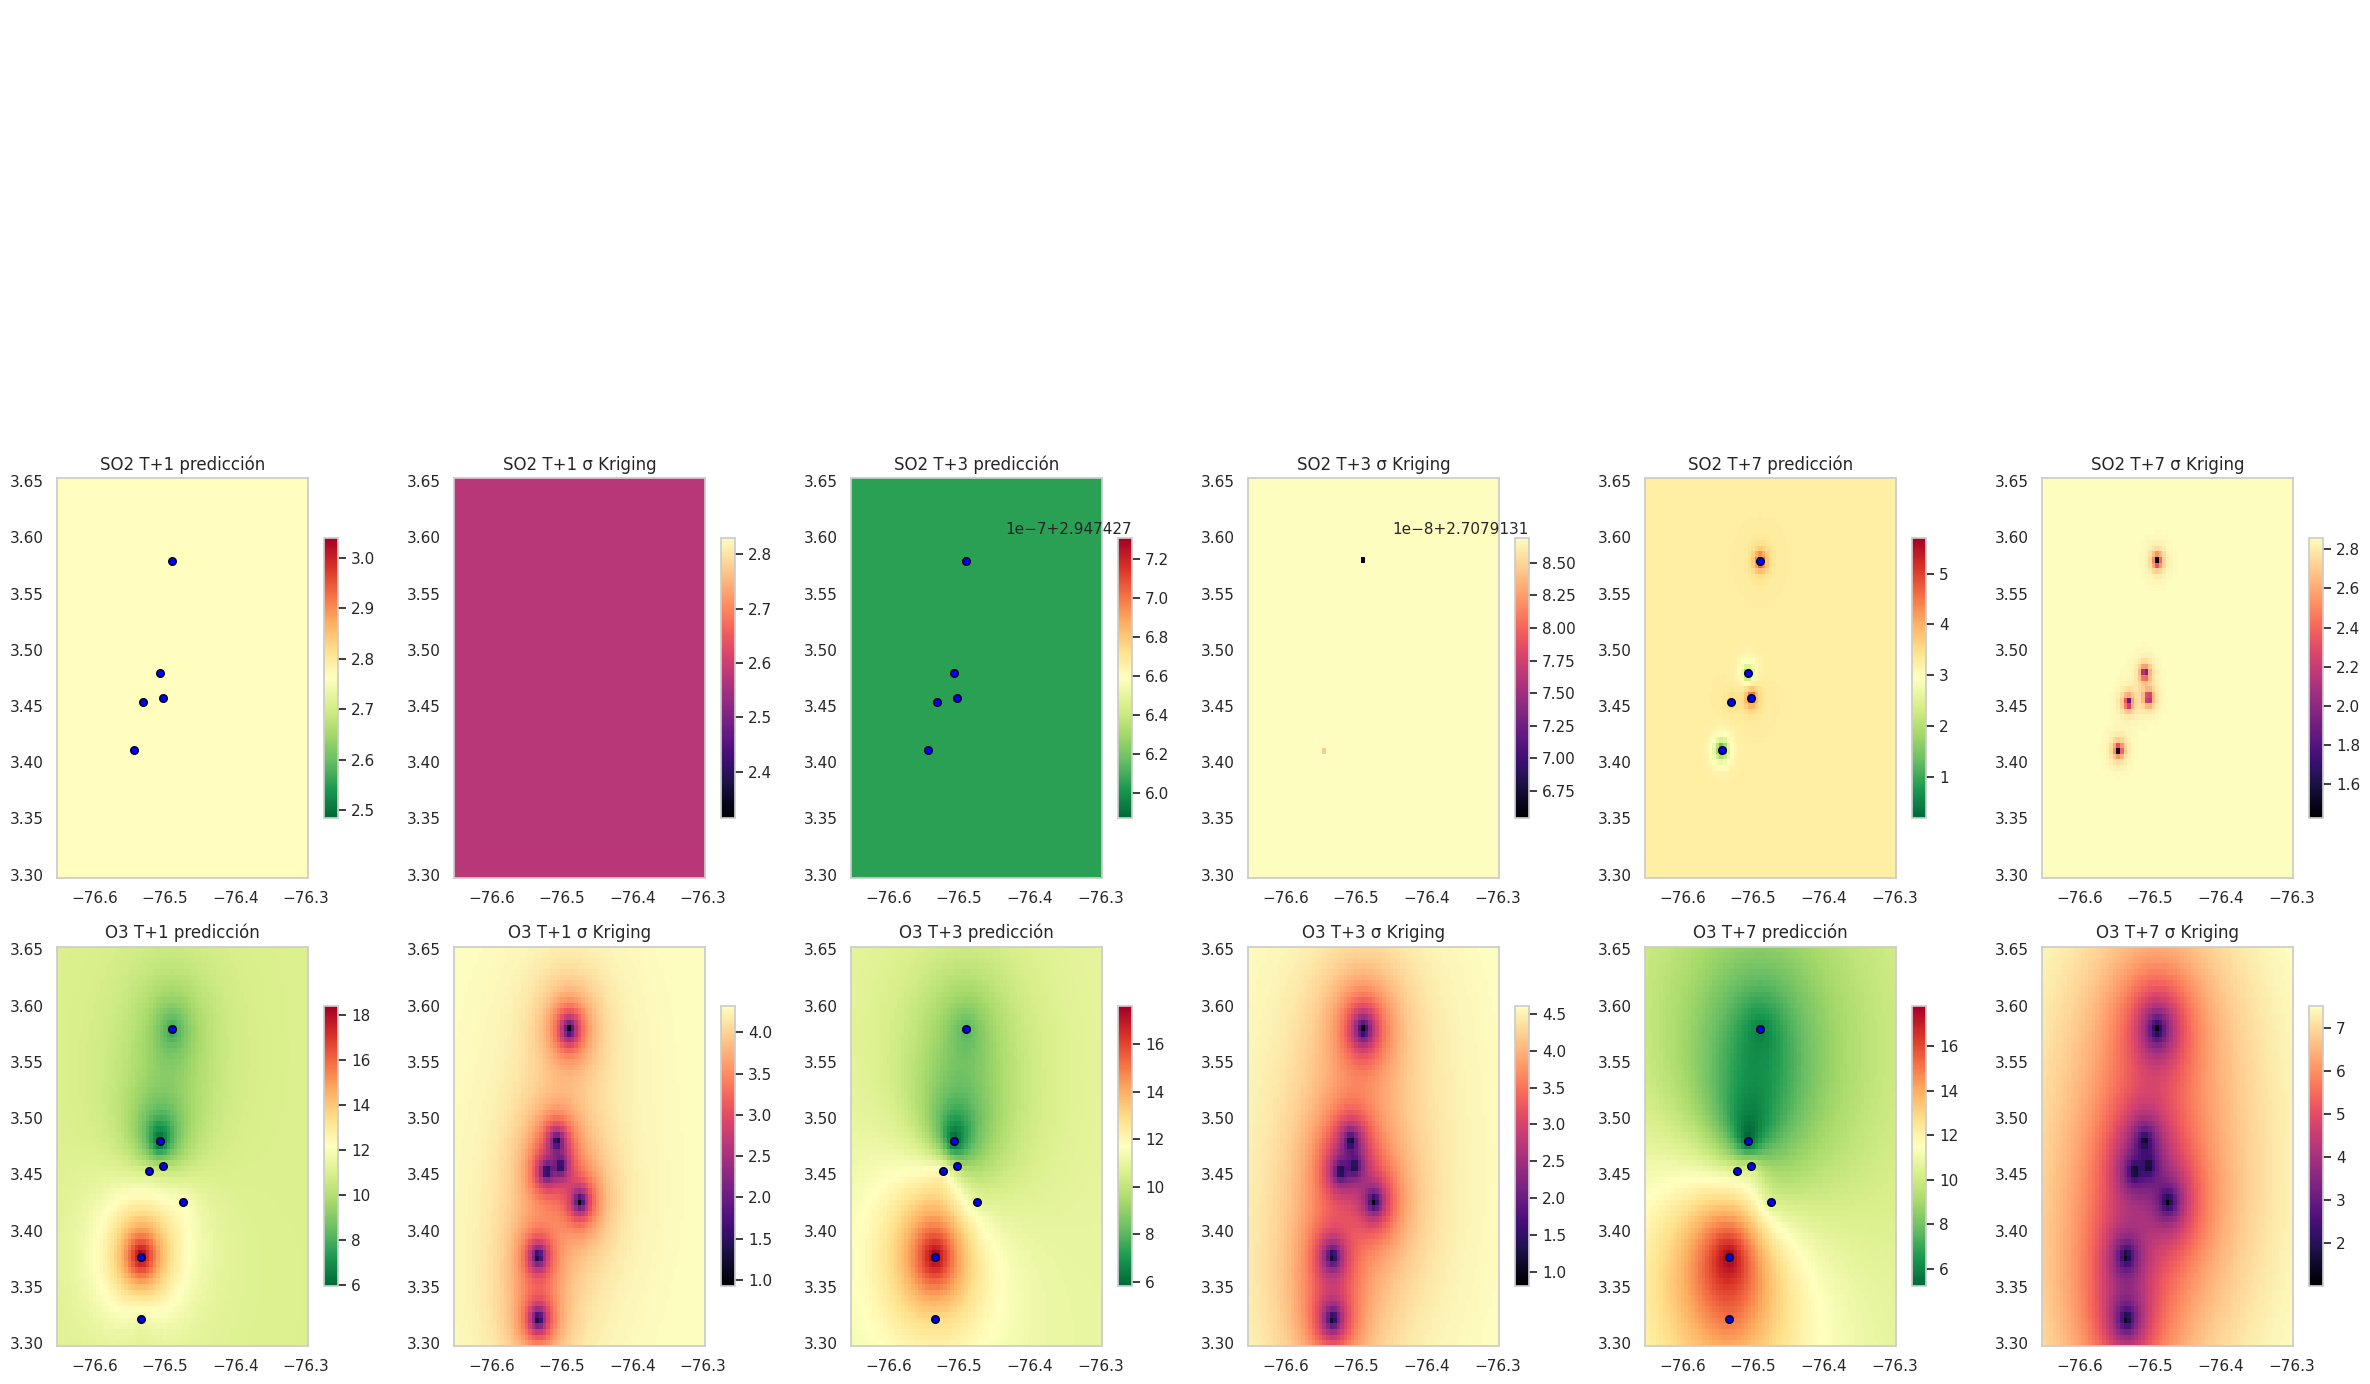

In [42]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
for i, gas in enumerate(POLLUTANTS):
    for j, h in enumerate(HORIZONS):
        key = (gas, h)
        if key not in kriging_models:
            for k in range(2): axes[i, j*2+k].axis('off')
            continue
        ok, obs = kriging_models[key]
        try:
            z_p, ss = ok.execute('grid', lon_grid, lat_grid)
            z_p = np.asarray(z_p)
            ss = np.asarray(ss)
            tendencia = obs.pred_cl.median()
            z_abs = z_p + tendencia
            
            im0 = axes[i, j*2].pcolormesh(lon_grid, lat_grid, z_abs, cmap='RdYlGn_r', shading='auto')
            axes[i, j*2].scatter(obs.longitud, obs.latitud, c='blue', s=30, edgecolor='black', label='DAGMA')
            axes[i, j*2].set_title(f'{gas} T+{h} predicción')
            plt.colorbar(im0, ax=axes[i, j*2], shrink=0.7)
            
            im1 = axes[i, j*2+1].pcolormesh(lon_grid, lat_grid, np.sqrt(ss), cmap='magma', shading='auto')
            axes[i, j*2+1].set_title(f'{gas} T+{h} σ Kriging')
            plt.colorbar(im1, ax=axes[i, j*2+1], shrink=0.7)
        except Exception as e:
            print(f'{gas} T+{h}: error mapa → {e}')
plt.tight_layout()
plt.savefig(WORKING / 'mapas_predicciones.png', dpi=140, bbox_inches='tight')
plt.show()

In [43]:
no2_est = dagma_diario[dagma_diario.gas == 'NO2'].groupby('nombre_est').agg(
    n_obs=('concentracion','size'), mean=('concentracion','mean'), std=('concentracion','std'),
    lat=('latitud','first'), lon=('longitud','first'),
).round(2)
print('NO2 — estaciones DAGMA disponibles:')
print(no2_est)
print(f'\nLimitación documentada: n={len(no2_est)} estaciones → LOO-CV con kriging variográfico requiere n≥3.')
print('Defensa: NO2 se reporta como interpolación lineal entre las 2 estaciones + comparación opcional con S5P TROPOMI L3 NO2 como segunda fuente independiente (referencia van Geffen et al. 2022).')

# Si hay datos para hacer ConvLSTM solo (sin kriging) sobre NO2:
no2_runs = [r for r in loocv_results if r['gas'] == 'NO2']
if no2_runs:
    y_true_no2 = np.concatenate([r['y_true'] for r in no2_runs])
    y_pred_no2 = np.concatenate([r['y_pred'] for r in no2_runs])
    rmse_no2 = np.sqrt(mean_squared_error(y_true_no2, y_pred_no2))
    r2_no2 = r2_score(y_true_no2, y_pred_no2)
    print(f'\nNO2 (sin kriging, solo ConvLSTM): RMSE={rmse_no2:.3f} µg/m³, R²={r2_no2:.3f}')

NO2 — estaciones DAGMA disponibles:
                n_obs   mean   std   lat    lon
nombre_est                                     
estacion yumbo    270   8.69  4.54  3.58 -76.49
univalle          963  10.13  4.62  3.38 -76.53

Limitación documentada: n=2 estaciones → LOO-CV con kriging variográfico requiere n≥3.
Defensa: NO2 se reporta como interpolación lineal entre las 2 estaciones + comparación opcional con S5P TROPOMI L3 NO2 como segunda fuente independiente (referencia van Geffen et al. 2022).

NO2 (sin kriging, solo ConvLSTM): RMSE=7.080 µg/m³, R²=-1.331


In [44]:
# === Subir/versionar embeddings como Kaggle Dataset (idempotente) ===
import shutil, subprocess

DATASET_SLUG_EMB = "edwardsx/geovision-sit3-embeddings"
ARTEFACTO_DIR_EMB = Path('/kaggle/working/sit3_embeddings_dataset')
ARTEFACTO_DIR_EMB.mkdir(parents=True, exist_ok=True)

if not EMB_CACHE.exists():
    print(f"ERROR: {EMB_CACHE} no existe. Ejecutar bloque B primero.")
else:
    shutil.copy(EMB_CACHE, ARTEFACTO_DIR_EMB / EMB_CACHE.name)
    
    metadata = {
        "title": "GeoVision Sit3 Embeddings CLIP-SAE Cali",
        "id": DATASET_SLUG_EMB,
        "licenses": [{"name": "CC0-1.0"}],
    }
    with open(ARTEFACTO_DIR_EMB / 'dataset-metadata.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    
    n_embs = len(np.load(EMB_CACHE).files)
    
    # Probar VERSIONAR primero (si ya existe el slug)
    cmd_version = ["kaggle", "datasets", "version", "-p", str(ARTEFACTO_DIR_EMB),
                   "-m", f"Embeddings sit3 — {n_embs} embeddings", "--dir-mode", "zip"]
    res = subprocess.run(cmd_version, capture_output=True, text=True)
    
    if res.returncode == 0:
        print(f"Dataset VERSIONADO: https://www.kaggle.com/datasets/{DATASET_SLUG_EMB}")
    else:
        print(f"Versionar falló (probablemente no existe), intentando crear...")
        print(f"  stderr: {res.stderr[:200]}")
        cmd_create = ["kaggle", "datasets", "create", "-p", str(ARTEFACTO_DIR_EMB), "--public"]
        res_c = subprocess.run(cmd_create, capture_output=True, text=True)
        if res_c.returncode == 0:
            print(f"Dataset CREADO: https://www.kaggle.com/datasets/{DATASET_SLUG_EMB}")
        else:
            print(f"STDOUT: {res_c.stdout}")
            print(f"STDERR: {res_c.stderr}")

Dataset VERSIONADO: https://www.kaggle.com/datasets/edwardsx/geovision-sit3-embeddings


In [45]:
resumen = {
    'fecha_ejecucion': datetime.utcnow().isoformat() + 'Z',
    'metricas_loocv': metricas_df.to_dict(orient='records'),
    'kpis': kpis_df.to_dict(orient='records'),
    'moran_resultados': {g: {'I': float(v['I']), 'p': float(v['p']), 'EI': float(v['EI'])} for g, v in moran_results.items()},
    'bbox': list(BBOX),
    'n_secuencias_por_gas_h': {f'{g}_h{h}': len(s) for (g,h), s in secuencias_gas_h.items()},
    'limitacion_no2': 'n=2 estaciones DAGMA → LOO-CV kriging inejecutable',
}

with open(WORKING / 'resumen_sit3.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2, default=str)

print('=== ARCHIVOS PERSISTIDOS ===')
for f in sorted(WORKING.iterdir()):
    print(f'  {f.name}: {f.stat().st_size/1024:.1f} KB')

print('\n=== KPIs Sit 3 final ===')
print(kpis_df.round(3).to_string())

=== ARCHIVOS PERSISTIDOS ===
  embeddings_sit3.npz: 5577.5 KB
  kpis_sit3.csv: 0.4 KB
  mapas_predicciones.png: 243.2 KB
  metricas_loocv.csv: 0.6 KB
  resumen_sit3.json: 3.3 KB

=== KPIs Sit 3 final ===
                              KPI  valor  minimo  excelente tipo  cumple      nivel
0             RMSE LOO-CV NO2 T+1  7.379    8.00       4.00  min    True         OK
1             RMSE LOO-CV SO2 T+1  4.078    6.00       3.00  min    True         OK
2              RMSE LOO-CV O3 T+1  8.636   12.00       6.00  min    True         OK
3        R² LOO-CV promedio (T+1) -0.911    0.55       0.75  max   False  NO CUMPLE
4  Degradación T+1 → T+7 (% RMSE)  0.009    0.60       0.30  min    True  EXCELENTE
